# Personal Expense Classifier & Visualizer using ML + NLP
This project classifies personal expense transactions into categories using Machine Learning and NLP techniques.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Load dataset
df = pd.read_csv('C:/Users/kavya/Desktop/personal_expense_data.csv')
df.head()


,Transaction_Description,Category
0,Dmart payment #4964,Groceries
1,Electricity Bill payment #5236,Bills
2,Spencer's payment #3518,Groceries
3,Bus Ticket payment #8474,Travel
4,Rent payment #1111,Rent


In [3]:
# Clean text data
df['Transaction_Description'] = df['Transaction_Description'].str.lower().str.replace('[^a-zA-Z ]', '', regex=True)
df.head()


,Transaction_Description,Category
0,dmart payment,Groceries
1,electricity bill payment,Bills
2,spencers payment,Groceries
3,bus ticket payment,Travel
4,rent payment,Rent


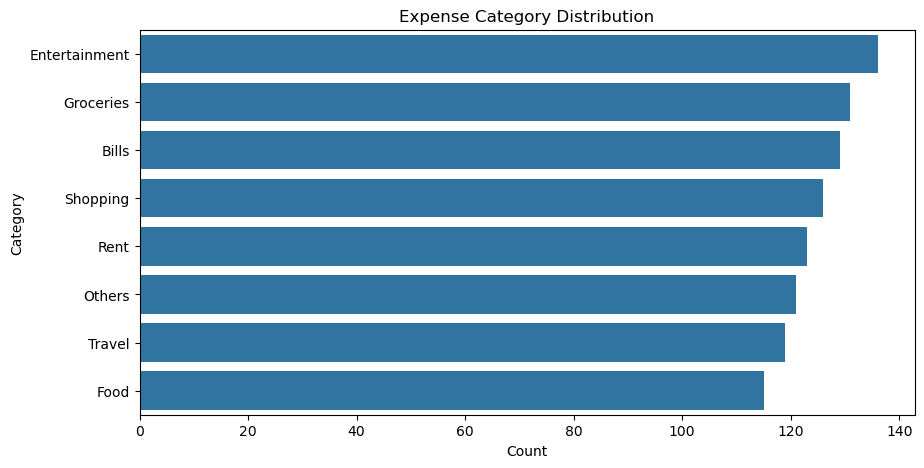

In [4]:
# Category distribution
plt.figure(figsize=(10,5))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index)
plt.title('Expense Category Distribution')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()


In [5]:
# Vectorize text data
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['Transaction_Description'])

# Labels
y = df['Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# Train Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00        24
Entertainment       1.00      1.00      1.00        29
         Food       1.00      1.00      1.00        20
    Groceries       1.00      1.00      1.00        30
       Others       1.00      1.00      1.00        22
         Rent       1.00      1.00      1.00        26
     Shopping       1.00      1.00      1.00        28
       Travel       1.00      1.00      1.00        21

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200



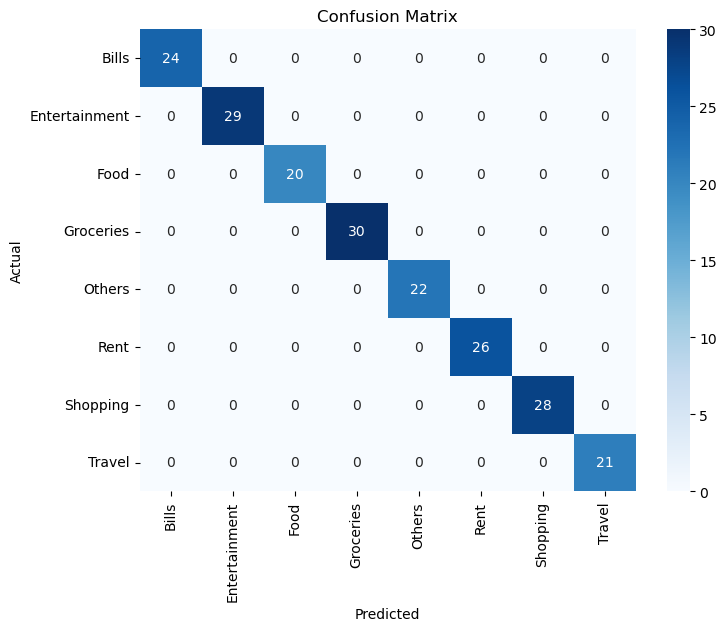

In [7]:
# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [8]:
import os

# Create 'models' folder if it doesn't exist
os.makedirs('models', exist_ok=True)


In [9]:
import joblib

# Save model
joblib.dump(model, 'models/rf_model.pkl')

# Save vectorizer
joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')


['models/tfidf_vectorizer.pkl']